In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from src.baselines import (
    FEATURE_COLS,
    stat_analysis,
    feat_engineering,
    split,
    isolation_forest,
    local_outlier_factor,
    prepare_lgb_dataset,
    evaluation,
    lgb_grid_search,
    show_cv_results,
)


In [2]:
df = pd.read_parquet("../data/processed/dataset_finale_2023-09-01_2025-09-30.parquet")


## Baseline 1: Classical Statistical Decomposition

One of the most classic methods for detecting anomalies in time series: decompose each series into its structural components and flag observations with unexpectedly large residuals. The intuition is simple: traffic follows a fairly regular rhythm (daily peaks, weekly patterns, August dips) and anything that cannot be explained by that rhythm is a candidate anomaly.

### Decomposition

The vehicle count series for each sensor is decomposed additively into three components:

$$y_t = T_t + S_t + R_t$$

where $T_t$ is the trend (long-run evolution), $S_t$ is the seasonal component (24h daily + 168h weekly), and $R_t$ is the residual, i.e. the part that the regular structure cannot explain.

Two implementations are available in `statsmodels`:

`seasonal_decompose`: classical decomposition using moving averages. Simple and fast, but assumes fixed seasonality and requires a complete, evenly-spaced series.

`STL` (Seasonal-Trend decomposition using LOESS): more robust, handles gradual changes in the seasonal shape and is less sensitive to outliers. Preferred when the pattern evolves over the two-year observation window.

### Anomaly scoring with MAD

Once the residuals $R_t$ are extracted, a modified z-score flags outliers without being distorted by the very outliers we are trying to find (the classic problem with the standard z-score):

$$\tilde{z}_t = \frac{0.6745 \cdot (R_t - \tilde{R})}{\text{MAD}}, \quad \text{MAD} = \text{median}(|R_t - \tilde{R}|)$$

The constant 0.6745 makes the score comparable to a standard normal z-score. A point is flagged when $|\tilde{z}_t| > \tau$, with $\tau \in [3, 4]$ (Iglewicz & Hoaglin 1993).

Why MAD instead of standard deviation? Because the standard deviation is inflated by the anomalies themselves, which raises the threshold and masks the points we want to catch. The median is insensitive to outliers by construction.

### Practical notes

Decompose per sensor: each `chiave` has its own traffic profile and must be treated independently.

Exclude event days and national holidays from the decomposition fit: a football match or a trade fair is not an anomaly in the sense of this project, it is a known and labelled disturbance. Including it in the residual distribution inflates the noise estimate.

The decomposition requires a continuous, regularly-sampled series (one row per hour). Missing hours must be imputed before fitting.

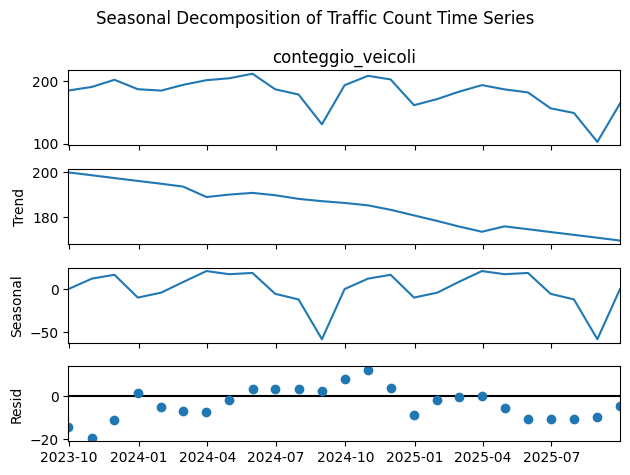

In [4]:
df = df.sort_values('data')

monthly = (
    df.set_index('data')['conteggio_veicoli']
      .resample('ME')
      .mean()
)

seasonal_decompose(
    monthly, 
    model='additive', 
    period=12, 
    extrapolate_trend='freq'
    ).plot()
plt.suptitle('Seasonal Decomposition of Traffic Count Time Series')
plt.tight_layout()
plt.show()


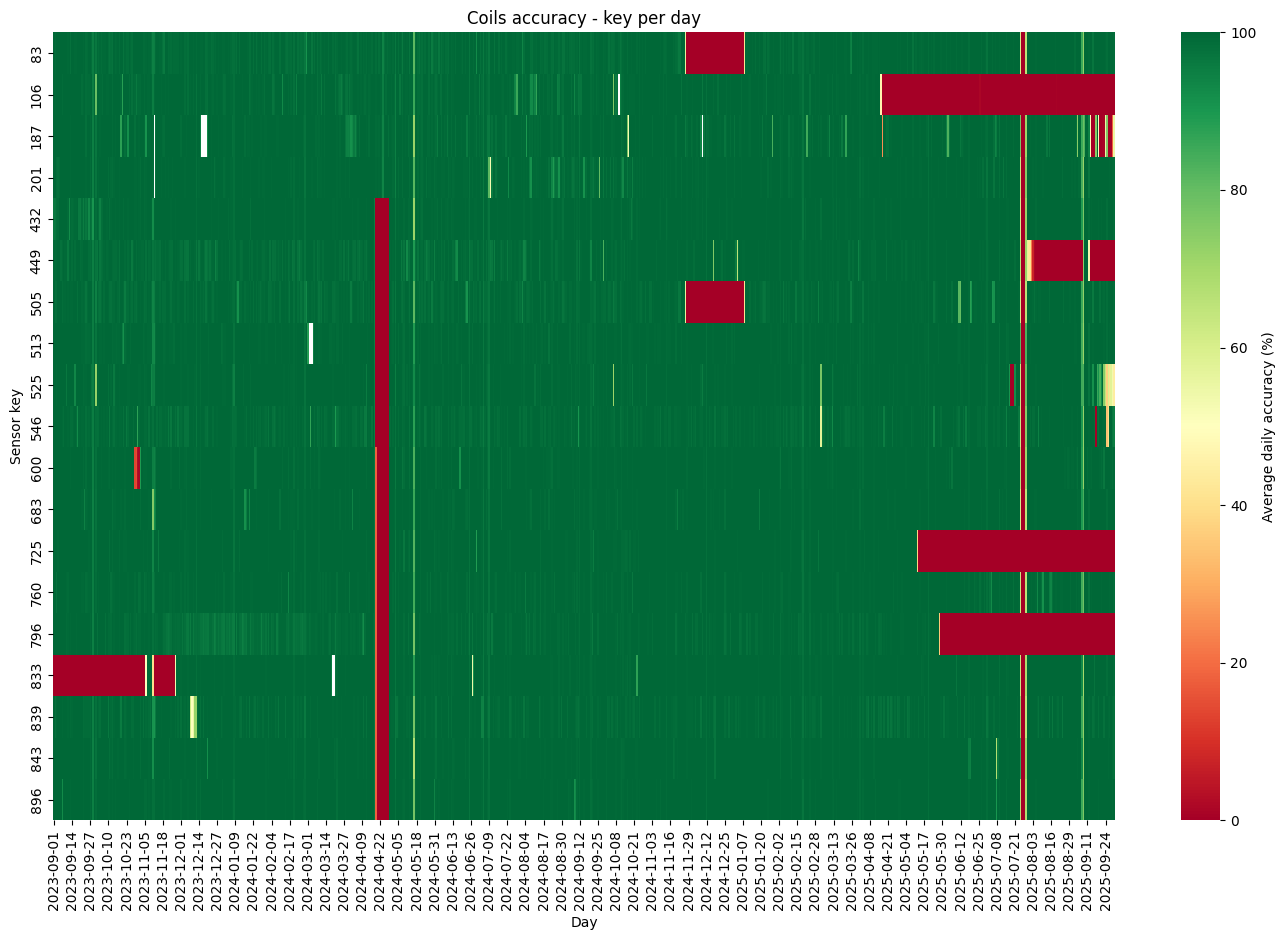

Anomalous sensor-days (|z_mod| > 3.5): 2715


,chiave,data,accuratezza,median_acc,MAD,modified_zscore
14394,896,2025-07-28,0.000000,100.000000,0.000000,-6.745000e+10
14393,896,2025-07-27,0.000000,100.000000,0.000000,-6.745000e+10
7847,600,2024-04-25,0.000000,100.000000,0.000000,-6.745000e+10
7846,600,2024-04-24,0.000000,100.000000,0.000000,-6.745000e+10
7848,600,2024-04-26,0.000000,100.000000,0.000000,-6.745000e+10
...,...,...,...,...,...,...
4796,505,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
7079,546,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
5137,505,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00
571,83,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00


In [5]:
acc_pivot = (
    df.assign(giorno=df['timestamp'].dt.date)
      .groupby(['chiave', 'giorno'])['accuratezza']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(14, max(2, len(acc_pivot) * 0.5)))
sns.heatmap(acc_pivot, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Average daily accuracy (%)'}, ax=ax)
ax.set_title('Coils accuracy - key per day')
ax.set_xlabel('Day')
ax.set_ylabel('Sensor key')
plt.tight_layout()
plt.show()

MAD_THRESHOLD = 3.5  # standard threshold for modified z-score

acc_long = (
    acc_pivot.stack()
             .rename('accuratezza')
             .reset_index()
             .rename(columns={'giorno': 'data'})
)

# per-sensor median and MAD
sensor_stats = (
    acc_long.groupby('chiave')['accuratezza']
            .agg(median_acc='median',
                 MAD=lambda x: (x - x.median()).abs().median())
            .reset_index()
)

acc_long = acc_long.merge(sensor_stats, on='chiave')
acc_long['residual'] = acc_long['accuratezza'] - acc_long['median_acc']
# modified z-score (Iglewicz & Hoaglin 1993): 0.6745 * residual / MAD
acc_long['modified_zscore'] = 0.6745 * acc_long['residual'] / (acc_long['MAD'] + 1e-9)
acc_long['is_anomaly'] = acc_long['modified_zscore'].abs() > MAD_THRESHOLD

anomalies = acc_long[acc_long['is_anomaly']].sort_values('modified_zscore')
print(f"Anomalous sensor-days (|z_mod| > {MAD_THRESHOLD}): {len(anomalies)}")
anomalies[['chiave', 'data', 'accuratezza', 'median_acc', 'MAD', 'modified_zscore']]

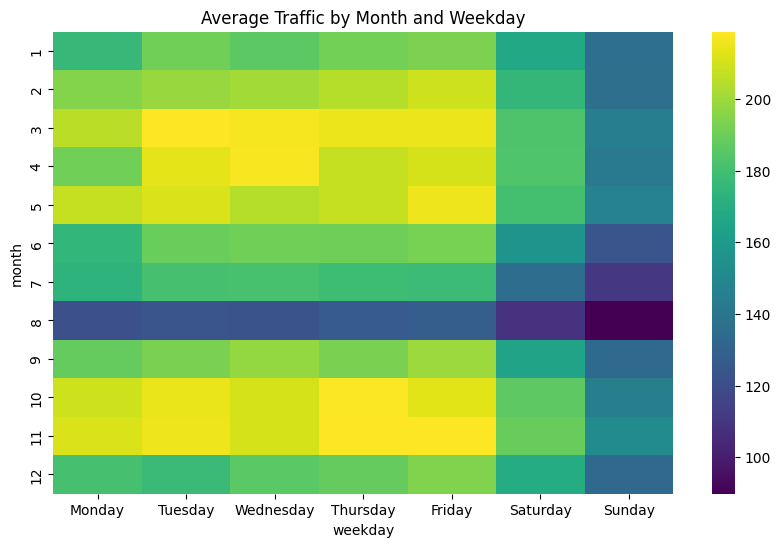

In [6]:
df['month'] = df['data'].dt.month
df['weekday'] = df['data'].dt.day_name()

heatmap_data = (
    df.groupby(['month', 'weekday'])['conteggio_veicoli']
      .mean()
      .unstack()
)

weekday_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

heatmap_data = heatmap_data[weekday_order]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Average Traffic by Month and Weekday')
plt.show()

In [8]:
month = df["data"].dt.month
df["season"] = np.select(
    [month.isin([12, 1, 2]), month.isin([3, 4, 5]),
     month.isin([6, 7, 8]),  month.isin([9, 10, 11])],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="",
)

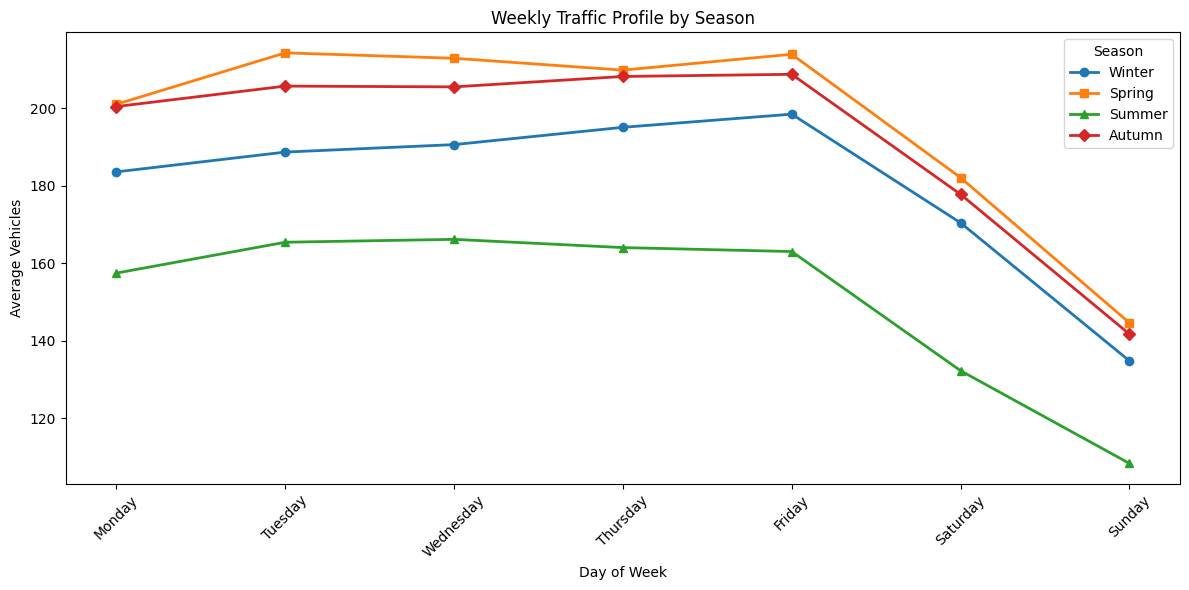

In [9]:
seasonal_week = (
    df.groupby(['season', 'weekday'])['conteggio_veicoli']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

markers = {
    'Winter': 'o',
    'Spring': 's',
    'Summer': '^',
    'Autumn': 'D'
}

for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    sub = seasonal_week[seasonal_week['season'] == season]

    sub = sub.set_index('weekday').reindex(weekday_order).reset_index()

    ax.plot(
        sub['weekday'],
        sub['conteggio_veicoli'],
        marker=markers[season],
        linewidth=2,
        label=season
    )

ax.set_title('Weekly Traffic Profile by Season')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Vehicles')
ax.legend(title='Season')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

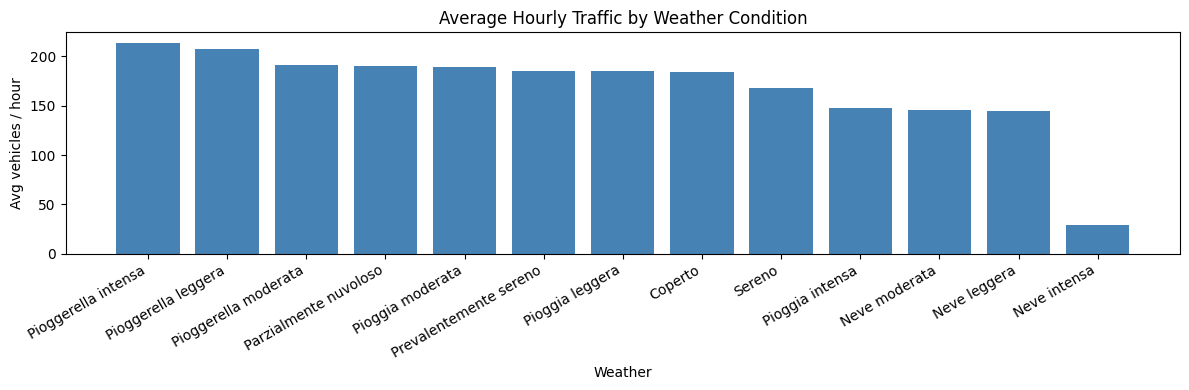

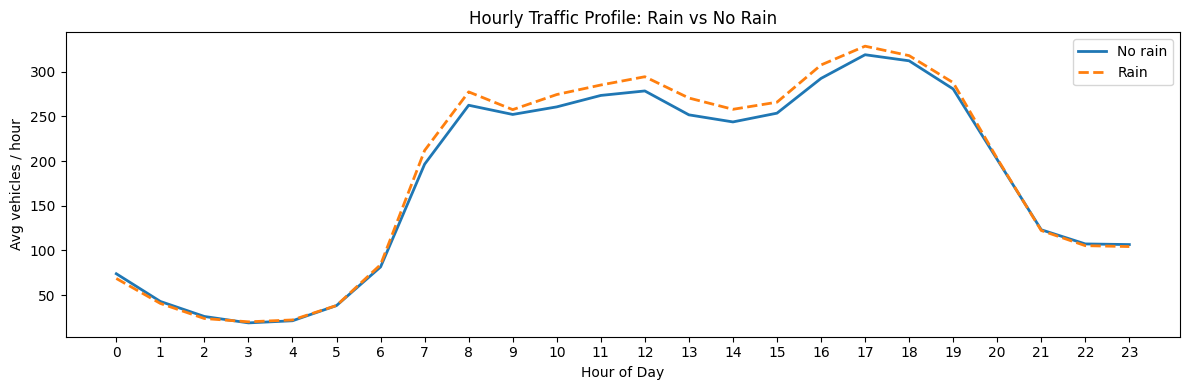

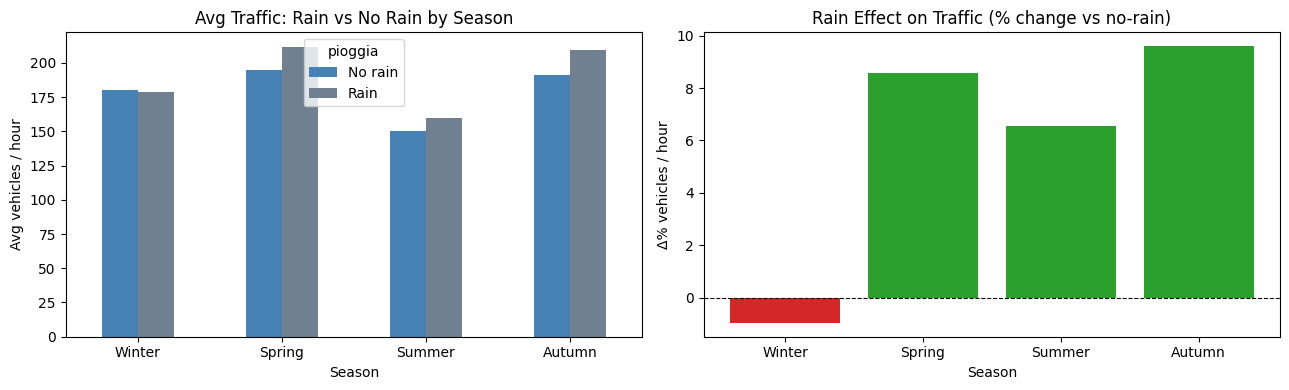

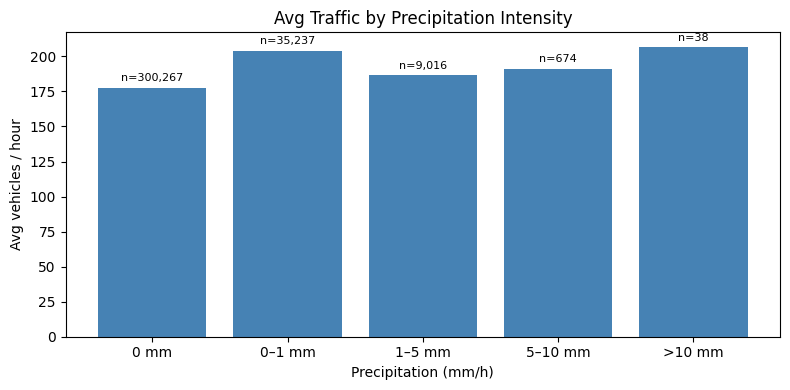

Pearson correlation with conteggio_veicoli:
precipitation     0.007275
wind_speed_10m    0.012142
pioggia           0.019331
temperature_2m    0.069523


In [10]:
weather_corr, precip_effect, df = stat_analysis(df)


## Baseline 2: Distance and Density-based Anomaly Detection

The core idea is to represent each hourly observation as a point in a feature space and flag points that are far from their neighbours or that live in unusually sparse regions. Unlike the statistical baseline, this approach does not decompose the series: it treats the problem as a one-class classification task where "normal" occupies a compact region and anomalies are the outliers.

### Feature engineering

Raw vehicle counts alone carry no temporal context, so each row is enriched before fitting:

`hour`, `dow` (day of week): encode the expected daily and weekly rhythm.

`lag_1h`, `lag_24h`, `lag_168h`: capture short-term autocorrelation and the same-hour-yesterday / same-hour-last-week baselines.

`rolling_mean_3h`, `rolling_mean_24h`: smooth the local trend; large deviations from the rolling mean are already a signal.

`temperature_2m`, `precipitation`, `wind_speed_10m`: weather moderates expected flow; including it prevents rain-induced drops from being flagged as anomalies.

Both algorithms are sensitive to feature scale; `isolation_forest` and `local_outlier_factor` in `src/baselines.py` currently fit directly on the raw `FEATURE_COLS` without standardisation, so features with larger numeric ranges (e.g. the lag/rolling-mean counts) can dominate over smaller-range ones (e.g. `dow`, `wind_speed_10m`). Adding a `StandardScaler` step before fitting is a natural improvement to make the two families of features comparable.

### Models

IsolationForest (`sklearn.ensemble`) partitions the feature space by randomly splitting on random features. Anomalies require fewer splits to isolate and receive a lower anomaly score. It scales well to large datasets and is robust to the curse of dimensionality.

LocalOutlierFactor (`sklearn.neighbors`) compares the local density of each point to its k nearest neighbours. A point in a sparser neighbourhood than its neighbours gets a high LOF score. It is more sensitive to local structure, useful for anomalies that are subtle in the global distribution but extreme in their local context (e.g. a single sensor behaving oddly while nearby sensors are normal).

### Contamination rate calibration

The `contamination` parameter controls the expected fraction of anomalies and directly sets the decision threshold. Rather than defaulting to `0.01`, it should be grounded in the problem:

A rate between `0.005` and `0.02` is reasonable if the project targets structural long-period anomalies (as in the three families defined in the project).

As a sanity check, the number of flagged hours should be in the same order of magnitude as known events in the dataset (matches, fairs, maintenance outages).

Avoid treating the contamination rate as a performance metric — it is a prior, not a result.

In [11]:
df_feat = feat_engineering(df)
train, test = split(df_feat)
print(f"Train: {train.shape}  |  Test: {test.shape}")


Train: (221599, 44)  |  Test: (123633, 44)


In [12]:
result_if = isolation_forest(train, test)
print("Flagged (IF):", (result_if["anomaly_isolation"] == -1).sum())
result_if[result_if["anomaly_isolation"] == -1][["data", "chiave", "conteggio_veicoli", "anomaly_score"]].head()


Flagged (IF): 790


,data,chiave,conteggio_veicoli,anomaly_score
338912,2025-01-09,896,1113,-0.693115
338911,2025-01-09,896,1110,-0.705904
338941,2025-01-10,896,1330,-0.689873
338940,2025-01-10,896,1214,-0.685514
338967,2025-01-11,896,951,-0.686730


In [13]:
result_lof = local_outlier_factor(df_feat)
print("Flagged (LOF):", (result_lof["anomaly_lof"] == -1).sum())
result_lof[result_lof["anomaly_lof"] == -1][["data", "chiave", "conteggio_veicoli", "lof_score"]].head()


Flagged (LOF): 3421


,data,chiave,conteggio_veicoli,lof_score
272712,2023-09-09,833,0,-1.584402
272711,2023-09-09,833,0,-1.528801
199965,2023-09-10,683,551,-1.401431
18431,2023-09-10,106,83,-1.354319
199962,2023-09-10,683,403,-1.336846


## Baseline 3: Forecasting-based Anomaly Detection

The idea is to train a model that predicts the expected value of a sensor for a specific hour given its context (lags, day of week, weather). 

A regressor like GradientBoostingRegressor, HistGradientBoostingRegressor or LightGBM works well. The difference between the observed and predicted value, normalised by the model's typical error, becomes the anomaly score.

In [15]:
gbm = prepare_lgb_dataset(df_feat)

Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[20]	valid_0's l2: 13278.1	valid_0's l1: 81.5452


In [16]:
_, test_feat = split(df_feat)
X_test = test_feat[FEATURE_COLS]
y_test = test_feat["conteggio_veicoli"]
mse, mae = evaluation(gbm, X_test, y_test)

Mean Squared Error: 13278.07
Mean Absolute Error: 81.55


### GridSearch

In [ ]:
gs = lgb_grid_search(df)
show_cv_results(gs)